In [8]:
import pandas as pd
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split,KFold,cross_val_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings("ignore")

## import data

In [9]:
wine_data=load_wine()
wine_data_df=pd.DataFrame(wine_data.data,columns= wine_data.feature_names)
wine_data_df["Target"]=wine_data.target
wine_data_df

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,Target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
173,13.71,5.65,2.45,20.5,95.0,1.68,0.61,0.52,1.06,7.70,0.64,1.74,740.0,2
174,13.40,3.91,2.48,23.0,102.0,1.80,0.75,0.43,1.41,7.30,0.70,1.56,750.0,2
175,13.27,4.28,2.26,20.0,120.0,1.59,0.69,0.43,1.35,10.20,0.59,1.56,835.0,2
176,13.17,2.59,2.37,20.0,120.0,1.65,0.68,0.53,1.46,9.30,0.60,1.62,840.0,2


# 3 data cleaning

In [10]:
wine_data_df.shape

(178, 14)

In [11]:
wine_data_df.isna().sum()

alcohol                         0
malic_acid                      0
ash                             0
alcalinity_of_ash               0
magnesium                       0
total_phenols                   0
flavanoids                      0
nonflavanoid_phenols            0
proanthocyanins                 0
color_intensity                 0
hue                             0
od280/od315_of_diluted_wines    0
proline                         0
Target                          0
dtype: int64

In [12]:
wine_data_df.dtypes

alcohol                         float64
malic_acid                      float64
ash                             float64
alcalinity_of_ash               float64
magnesium                       float64
total_phenols                   float64
flavanoids                      float64
nonflavanoid_phenols            float64
proanthocyanins                 float64
color_intensity                 float64
hue                             float64
od280/od315_of_diluted_wines    float64
proline                         float64
Target                            int64
dtype: object

# 4 model building

In [13]:
X=wine_data_df.drop("Target",axis=1)
y=wine_data_df["Target"]

In [14]:
std_scaler=StandardScaler()
scaled_x=std_scaler.fit_transform(X)
X_train,X_test,y_train,y_test=train_test_split(scaled_x,y, test_size=0.20, random_state=1234,shuffle=True,stratify=y,)

In [33]:
X_train,X_test,y_train,y_test=train_test_split(X,y, test_size=0.20, random_state=1234,shuffle=True,stratify=y,)

In [15]:
X_train.shape,y_train.shape

((142, 13), (142,))

In [16]:
X_test.shape,y_test.shape

((36, 13), (36,))

# 5 model training || 6.model test || 7.model evaluation

### neighbors3 when k=3

In [17]:
knn_model=KNeighborsClassifier(n_neighbors=3,)
knn_model.fit(X_train,y_train)
y_pred_train=knn_model.predict(X_train)
print("Accuracy score:",accuracy_score(y_train,y_pred_train))

Accuracy score: 0.9577464788732394


### neighbors5 when k=5

In [18]:
knn_model=KNeighborsClassifier(n_neighbors=5,)
knn_model.fit(X_train,y_train)
y_pred_train=knn_model.predict(X_train)
print("Accuracy score:",accuracy_score(y_train,y_pred_train))

Accuracy score: 0.9788732394366197


### neighbors7 when k=7

In [19]:
knn_model=KNeighborsClassifier(n_neighbors=7,)
knn_model.fit(X_train,y_train)
y_pred_train=knn_model.predict(X_train)
print("Accuracy score:",accuracy_score(y_train,y_pred_train))

Accuracy score: 0.971830985915493


### neighbors9 when k=9

In [20]:
knn_model=KNeighborsClassifier(n_neighbors=9,)
knn_model.fit(X_train,y_train)
y_pred_train=knn_model.predict(X_train)
print("Accuracy score:",accuracy_score(y_train,y_pred_train))

Accuracy score: 0.971830985915493


# how to choose the optimal no of of neighbours

In [21]:
from sklearn.model_selection import train_test_split,KFold,cross_val_score

In [22]:
kfold=KFold(n_splits=5, shuffle=True, random_state=123)
cv_score_mean=[]
for i in range(3,52,2):
    knn_classifier=KNeighborsClassifier(n_neighbors=i)
    knn_classifier.fit(scaled_x,y)
    cv_score=(cross_val_score(estimator=knn_classifier,X=scaled_x, y=y, cv=kfold))
    cv_score_mean.append(cv_score.mean().round(4))

In [23]:
cv_score_mean

[np.float64(0.949),
 np.float64(0.9605),
 np.float64(0.9603),
 np.float64(0.966),
 np.float64(0.966),
 np.float64(0.966),
 np.float64(0.9605),
 np.float64(0.9605),
 np.float64(0.966),
 np.float64(0.9716),
 np.float64(0.9773),
 np.float64(0.9773),
 np.float64(0.9773),
 np.float64(0.9716),
 np.float64(0.9773),
 np.float64(0.9716),
 np.float64(0.9603),
 np.float64(0.9602),
 np.float64(0.9602),
 np.float64(0.9489),
 np.float64(0.9433),
 np.float64(0.949),
 np.float64(0.949),
 np.float64(0.9548),
 np.float64(0.9605)]

In [24]:
max(cv_score_mean)

np.float64(0.9773)

In [25]:
cv_score_mean.index(max(cv_score_mean))

10

# lets visualize

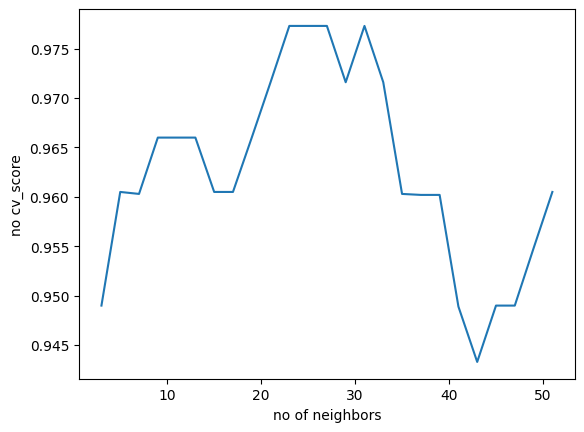

In [94]:
from matplotlib import pyplot as plt
plt.plot(range(3,52,2),cv_score_mean)
plt.xlabel("no of neighbors")
plt.ylabel("no cv_score")
plt.show()

In [29]:
kfold=KFold(n_splits=5,shuffle=True,random_state=123)
cross_cores_val=[]

for i in range (3,52,2):
    knn_classifier=KNeighborsClassifier( n_neighbors=i,)
    knn_classifier.fit(scaled_x,y)
    cross_scores=(cross_val_score(estimator=knn_classifier,X=scaled_x,y=y,cv=kfold,))
    cross_cores_val.append(cross_scores.mean().round(4))
    

In [ ]:
kfold=KFold(n_splits=5, shuffle=True, random_state=123)
cv_score_mean=[]
for i in range(3,52,2):
    knn_classifier=KNeighborsClassifier(n_neighbors=i)
    knn_classifier.fit(scaled_x,y)
    cv_score=(cross_val_score(estimator=knn_classifier,X=scaled_x, y=y, cv=kfold))
    cv_score_mean.append(cv_score.mean().round(4))

In [30]:
cross_cores_val

[np.float64(0.949),
 np.float64(0.9605),
 np.float64(0.9603),
 np.float64(0.966),
 np.float64(0.966),
 np.float64(0.966),
 np.float64(0.9605),
 np.float64(0.9605),
 np.float64(0.966),
 np.float64(0.9716),
 np.float64(0.9773),
 np.float64(0.9773),
 np.float64(0.9773),
 np.float64(0.9716),
 np.float64(0.9773),
 np.float64(0.9716),
 np.float64(0.9603),
 np.float64(0.9602),
 np.float64(0.9602),
 np.float64(0.9489),
 np.float64(0.9433),
 np.float64(0.949),
 np.float64(0.949),
 np.float64(0.9548),
 np.float64(0.9605)]

In [31]:
max(cross_cores_val)

np.float64(0.9773)

In [33]:
cross_cores_val.index(max(cross_cores_val))

10

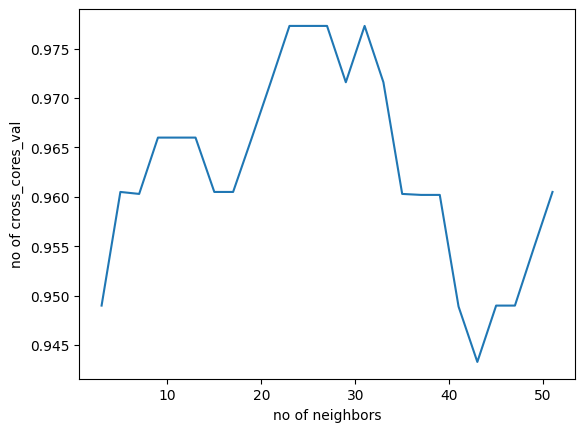

In [37]:
from matplotlib import pyplot as plt
plt.plot(range(3,52,2),cross_cores_val)
plt.xlabel("no of neighbors")
plt.ylabel("no of cross_cores_val")
plt.show()